In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install nibabel

In [ ]:
import nibabel as nib
import matplotlib.pyplot as plt

In [ ]:
ct = nib.load('/content/drive/MyDrive/LITS/volume-0.nii')
ct_data = ct.get_fdata()

print("CT shape:", ct_data.shape)

#75 slices of 512 x 512 image resolution

CT shape: (512, 512, 75)


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

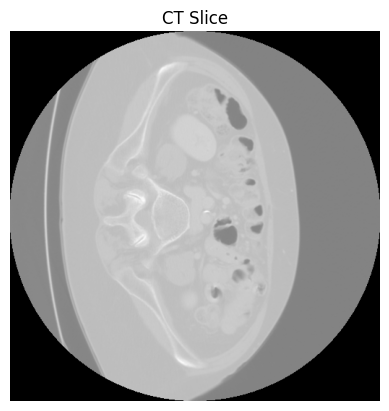

In [ ]:
slice_idx= ct_data.shape[2]//2 #choose the middle slice where the liver is clearly visible.
plt.imshow(ct_data[:,:, slice_idx], cmap = 'gray')
plt.title("CT Slice")
plt.axis('off')

In [ ]:
mask = nib.load('/content/drive/MyDrive/LITS/segmentation-0.nii')
mask_data = mask.get_fdata()

print("Mask shape:", mask_data.shape)

Mask shape: (512, 512, 75)


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

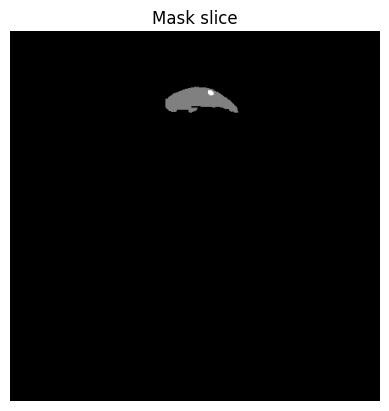

In [ ]:
slice_idx = 46
plt.imshow(mask_data[:,:,slice_idx], cmap='gray')
plt.title("Mask slice")
plt.axis('off')

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

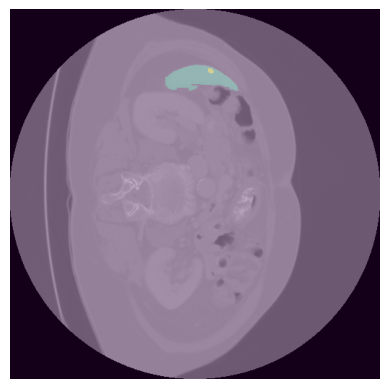

In [ ]:
slice_idx = 46

plt.imshow(ct_data[:, :, slice_idx], cmap='gray')
plt.imshow(mask_data[:, :, slice_idx], alpha=0.3)
plt.axis('off')


3D VISUALISATION

In [ ]:
import numpy as np

In [ ]:
liver_mask= (mask_data==1)|(mask_data==2)

In [ ]:
!pip install scikit-image

In [ ]:
from skimage import measure

verts, faces, normals, values = measure.marching_cubes(liver_mask, level = 0)

In [ ]:
spacing= ct.header.get_zooms()

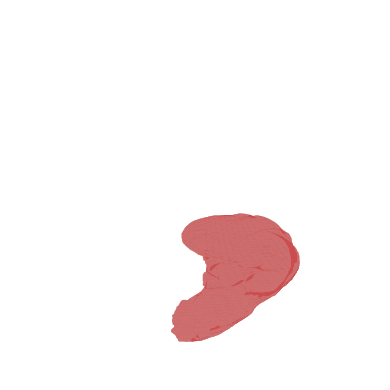

In [ ]:
from mpl_toolkits.mplot3d.art3d import Poly3DCollection


fig = plt.figure(figsize=(4,4))
ax = fig.add_subplot(111, projection='3d')

mesh = Poly3DCollection(verts[faces], alpha=0.7)
mesh.set_facecolor([0.8, 0.3, 0.3])
ax.add_collection3d(mesh)

ax.set_xlim(0, liver_mask.shape[0]*spacing[0])
ax.set_ylim(0, liver_mask.shape[1]*spacing[1])
ax.set_zlim(0, liver_mask.shape[2]*spacing[2])

plt.tight_layout()
plt.axis('off')

ax.view_init(elev=35, azim=45)
plt.show()


Prediction

In [ ]:
import numpy as np
pred_volume = np.load("/content/drive/MyDrive/pred_volume.npy")

In [ ]:
import scipy.ndimage as ndi

labeled, num = ndi.label(pred_volume)
sizes = ndi.sum(pred_volume, labeled, range(1, num+1))
largest = (sizes.argmax() + 1)
pred_volume_clean = (labeled == largest).astype(np.uint8)


In [ ]:
verts, faces, normals, values = measure.marching_cubes(pred_volume_clean, level = 0)

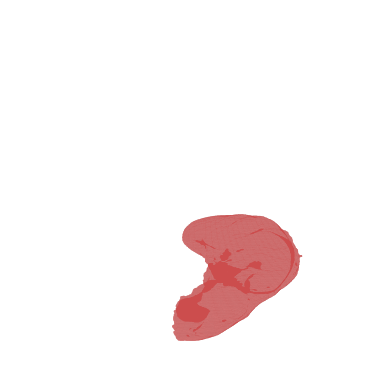

In [ ]:
from mpl_toolkits.mplot3d.art3d import Poly3DCollection


fig = plt.figure(figsize=(4,4))
ax = fig.add_subplot(111, projection='3d')

mesh = Poly3DCollection(verts[faces], alpha=0.7)
mesh.set_facecolor([0.8, 0.3, 0.3])
ax.add_collection3d(mesh)

ax.set_xlim(0, pred_volume.shape[0]*spacing[0])
ax.set_ylim(0, pred_volume.shape[1]*spacing[1])
ax.set_zlim(0, pred_volume.shape[2]*spacing[2])

plt.tight_layout()
plt.axis('off')

ax.view_init(elev=35, azim=45)
plt.show()